## Partie C : Implémentation Numérique par Méthodes de Monte-Carlo
Dans cette partie, nous allons évaluer les prix et les sensibilités (le "Grec" Delta $\Delta$) pour deux options asiatiques dans le cadre du modèle de Black-Scholes.
Les paramètres fournis par l'énoncé sont :
- Prix initial : $x = 100$
- Taux sans risque : $r = 0.03$ (soit $3\%$)
- Volatilité : $\sigma = 0.20$ (soit $20\%$)
- Maturité : $T = 1$ an

La dynamique de l'actif sous la probabilité risque-neutre est : $$dX_t^x = r X_t^x dt + \sigma X_t^x dB_t$$

Dont la solution explicite nous permet de simuler exactement les trajectoires (sans erreur de discrétisation d'Euler) :$$X_t^x = x \exp\left( \left(r - \frac{\sigma^2}{2}\right)t + \sigma B_t \right)$$L'intégrale de la trajectoire, nécessaire pour les options asiatiques, sera approchée par la somme de Riemann définie dans l'énoncé :$$\int_0^T X_s^x ds \approx \frac{T}{M} \sum_{k=0}^M X_{\frac{kT}{M}}$$Nous testerons pour $M \in \{50, 150, 250\}$.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# Paramètres globaux du modèle
x = 100.0
r = 0.03
sigma = 0.20
T = 1.0
K1 = 100.0
K2 = 110.0

def simuler_trajectoires(N, M):
    """
    Simule N trajectoires du modèle de Black-Scholes discrétisées en M pas de temps.
    Retourne la matrice des trajectoires X (N x M+1) et l'approximation de l'intégrale (N).
    """
    dt = T / M
    # Génération des accroissements browniens
    Z = np.random.randn(N, M)
    W = np.sqrt(dt) * Z
    
    # Construction du mouvement brownien (B_0 = 0)
    B = np.hstack((np.zeros((N, 1)), np.cumsum(W, axis=1)))
    
    # Grille de temps
    t = np.linspace(0, T, M + 1)
    
    # Calcul vectoriel des trajectoires exactes
    X = x * np.exp((r - 0.5 * sigma**2) * t + sigma * B)
    
    # Approximation de l'intégrale selon l'équation (9) du projet
    int_X = (T / M) * np.sum(X, axis=1)
    
    # On retourne aussi le premier accroissement brownien B_{t_1} (utile pour Malliavin Part A)
    B_t1 = B[:, 1]
    
    return X, int_X, B_t1

### Question a 
Nous devons pricer deux options asiatiques :
- Un Call Asiatique de payoff : $\Phi_1 = \left( \int_0^T X_s^x ds - K_1 \right)_+$ 
- Une Option Digitale Asiatique de payoff : $\Phi_2 = \mathbf{1}_{\left\{ K_1 < \int_0^T X_s^x ds < K_2 \right\}}$  

L'estimateur de Monte-Carlo pour le prix est donné par la moyenne empirique des payoffs actualisés :$$\hat{P}_N = \frac{1}{N} \sum_{j=1}^N e^{-rT} \Phi^{(j)}$$La variance empirique de l'estimateur est $V_N = \frac{1}{N-1} \sum_{j=1}^N \left( e^{-rT} \Phi^{(j)} - \hat{P}_N \right)^2$.L'intervalle de confiance asymptotique à $95\%$ est obtenu via le Théorème Central Limite :$$IC_{95\%} = \left[ \hat{P}_N - 1.96 \frac{\sqrt{V_N}}{\sqrt{N}} , \hat{P}_N + 1.96 \frac{\sqrt{V_N}}{\sqrt{N}} \right]$$Nous étudierons la convergence pour $N$ allant de $1000$ à $51000$ avec un pas de $2000$.


--- Résultats pour M = 50 pas de discrétisation ---
Call Asiatique     : Prix = 6.4835, Variance = 71.8370, IC 95% = [6.4099, 6.5570]
Digitale Asiatique : Prix = 0.3062, Variance = 0.2034, IC 95% = [0.3023, 0.3102]

--- Résultats pour M = 150 pas de discrétisation ---
Call Asiatique     : Prix = 5.6090, Variance = 62.9192, IC 95% = [5.5402, 5.6779]
Digitale Asiatique : Prix = 0.2969, Variance = 0.2000, IC 95% = [0.2930, 0.3008]

--- Résultats pour M = 250 pas de discrétisation ---
Call Asiatique     : Prix = 5.5401, Variance = 62.4153, IC 95% = [5.4715, 5.6086]
Digitale Asiatique : Prix = 0.2941, Variance = 0.1989, IC 95% = [0.2903, 0.2980]


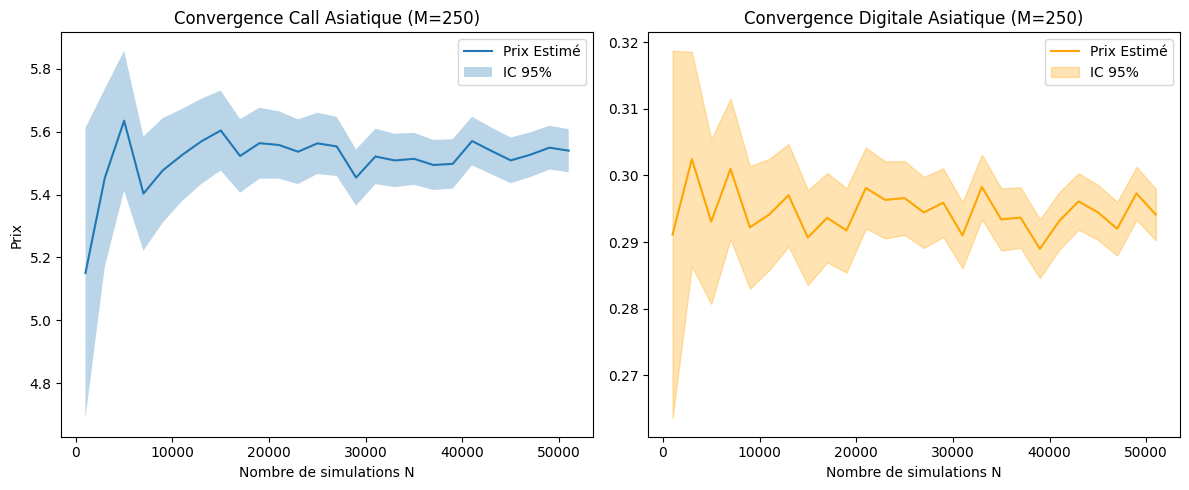

In [6]:
def payoffs(int_X):
    """Calcule les payoffs actualisés des deux options."""
    payoff_call = np.maximum(int_X - K1, 0) * np.exp(-r * T)
    payoff_digitale = ((int_X > K1) & (int_X < K2)).astype(float) * np.exp(-r * T)
    return payoff_call, payoff_digitale

N_values = np.arange(1000, 51001, 2000)
M_values = [50, 150, 250]

# Dictionnaires pour stocker les résultats pour les plots futurs
results_prix = {M: {'call': [], 'digitale': [], 'ic_call': [], 'ic_digitale': []} for M in M_values}

for M in M_values:
    print(f"\n--- Résultats pour M = {M} pas de discrétisation ---")
    for N in N_values:
        X, int_X, _ = simuler_trajectoires(N, M)
        p_call, p_dig = payoffs(int_X)
        
        # Moyennes
        mean_call, mean_dig = np.mean(p_call), np.mean(p_dig)
        # Variances empiriques
        var_call, var_dig = np.var(p_call, ddof=1), np.var(p_dig, ddof=1)
        # Demi-largeur de l'intervalle de confiance (1.96 * ecart_type / sqrt(N))
        hw_call = 1.96 * np.sqrt(var_call / N)
        hw_dig = 1.96 * np.sqrt(var_dig / N)
        
        results_prix[M]['call'].append(mean_call)
        results_prix[M]['digitale'].append(mean_dig)
        results_prix[M]['ic_call'].append(hw_call)
        results_prix[M]['ic_digitale'].append(hw_dig)
        
        # On affiche uniquement le résultat pour le plus grand N demandé
        if N == N_values[-1]:
            print(f"Call Asiatique     : Prix = {mean_call:.4f}, Variance = {var_call:.4f}, IC 95% = [{mean_call-hw_call:.4f}, {mean_call+hw_call:.4f}]")
            print(f"Digitale Asiatique : Prix = {mean_dig:.4f}, Variance = {var_dig:.4f}, IC 95% = [{mean_dig-hw_dig:.4f}, {mean_dig+hw_dig:.4f}]")

# Graphique de convergence (Exemple pour M=250)
M_plot = 250
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(N_values, results_prix[M_plot]['call'], label='Prix Estimé')
plt.fill_between(N_values, 
                 np.array(results_prix[M_plot]['call']) - np.array(results_prix[M_plot]['ic_call']), 
                 np.array(results_prix[M_plot]['call']) + np.array(results_prix[M_plot]['ic_call']), 
                 alpha=0.3, label='IC 95%')
plt.title(f'Convergence Call Asiatique (M={M_plot})')
plt.xlabel('Nombre de simulations N')
plt.ylabel('Prix')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(N_values, results_prix[M_plot]['digitale'], label='Prix Estimé', color='orange')
plt.fill_between(N_values, 
                 np.array(results_prix[M_plot]['digitale']) - np.array(results_prix[M_plot]['ic_digitale']), 
                 np.array(results_prix[M_plot]['digitale']) + np.array(results_prix[M_plot]['ic_digitale']), 
                 color='orange', alpha=0.3, label='IC 95%')
plt.title(f'Convergence Digitale Asiatique (M={M_plot})')
plt.xlabel('Nombre de simulations N')
plt.legend()
plt.tight_layout()
plt.show()

### Question b

La méthode des différences finies (différence centrale) approxime la dérivée de la fonction de prix en perturbant légèrement le point de départ $x$ d'une quantité $h$ :$$\Delta_{DF}(x) \approx \frac{P(x+h) - P(x-h)}{2h}$$Pour limiter la variance, nous utilisons la technique des variables aléatoires communes (Common Random Numbers) : nous réutilisons exactement les mêmes tirages gaussiens (donc la même intégrale de base) pour calculer la trajectoire partant de $x+h$ et celle partant de $x-h$.

Dans le modèle de Black-Scholes, la trajectoire $X$ est purement proportionnelle à $x$. Ainsi, modifier la condition initiale revient simplement à redimensionner l'intégrale :$$\int_0^T X_s^{x \pm h} ds = \frac{x \pm h}{x} \int_0^T X_s^x ds$$Nous testerons l'impact du pas $h$ sur la variance.

In [7]:
def delta_differences_finies(int_X, h_values):
    N = len(int_X)
    resultats = {}
    
    for h in h_values:
        # Trajectoires perturbées (Variables communes)
        int_X_up = ((x + h) / x) * int_X
        int_X_down = ((x - h) / x) * int_X
        
        p_call_up, p_dig_up = payoffs(int_X_up)
        p_call_down, p_dig_down = payoffs(int_X_down)
        
        # Estimateur DF
        delta_call = (p_call_up - p_call_down) / (2 * h)
        delta_dig = (p_dig_up - p_dig_down) / (2 * h)
        
        resultats[h] = {
            'call_mean': np.mean(delta_call), 'call_var': np.var(delta_call, ddof=1),
            'dig_mean': np.mean(delta_dig), 'dig_var': np.var(delta_dig, ddof=1)
        }
    return resultats

# Tests pour N fixe et M=250 avec différents h
N_fixe = 50000
M_fixe = 250
_, int_X, _ = simuler_trajectoires(N_fixe, M_fixe)
h_test = [1.0, 0.1, 0.01, 0.001]

res_df = delta_differences_finies(int_X, h_test)
print(f"--- Méthode des Différences Finies (N={N_fixe}, M={M_fixe}) ---")
for h in h_test:
    print(f"h = {h:<6} | Delta Call = {res_df[h]['call_mean']:>7.4f} (Var: {res_df[h]['call_var']:>8.4f}) | Delta Digitale = {res_df[h]['dig_mean']:>7.4f} (Var: {res_df[h]['dig_var']:>8.4f})")

--- Méthode des Différences Finies (N=50000, M=250) ---
h = 1.0    | Delta Call =  0.5740 (Var:   0.2791) | Delta Digitale =  0.0073 (Var:   0.0283)
h = 0.1    | Delta Call =  0.5740 (Var:   0.2886) | Delta Digitale =  0.0043 (Var:   0.2844)
h = 0.01   | Delta Call =  0.5739 (Var:   0.2895) | Delta Digitale =  0.0116 (Var:   2.7310)
h = 0.001  | Delta Call =  0.5740 (Var:   0.2896) | Delta Digitale =  0.0485 (Var:  32.9601)


### Question c

Plutôt que de dériver le payoff, l'Intégration par Parties (IBP) de Malliavin dérive la densité de probabilité, ce qui permet d'exprimer $\Delta(x)$ comme l'espérance du payoff multiplié par un poids $\Pi$ : $\Delta(x) = E[ e^{-rT} \Phi(X) \Pi ]$.

##### Méthode issue de la Partie A (Discrète) :
D'après la question A.d), pour un modèle de Black-Scholes standard, le poids $\Pi_A$ construit à partir de la suite des $\lambda_i$ se simplifie massivement pour devenir le poids classique de Black-Scholes basé uniquement sur le premier pas de temps :$$\Pi_A = \frac{B_{t_1}}{x \sigma t_1}$$où $t_1 = \frac{T}{M}$.

##### Méthode issue de la Partie B (Continue) :
La question B.a) et B.b) nous donnent un poids $\Pi_B$ global basé sur toute la trajectoire continue. D'après le théorème de dualité et nos calculs de la partie B, on obtient la formule explicite sans intégrale stochastique :$$\Pi_B = \frac{2}{\sigma x} \left[ \frac{X_T - x}{\sigma \int_0^T X_s ds} - \frac{r}{\sigma} + \frac{\sigma}{2} \right]$$Ce poids utilise toute l'information de l'intégrale et de la valeur finale $X_T$.

In [10]:
def delta_malliavin(X, int_X, B_t1, M):
    N = len(int_X)
    dt = T / M
    p_call, p_dig = payoffs(int_X)
    
    # --- Poids Méthode Partie A ---
    # t1 est simplement dt
    Pi_A = B_t1 / (x * sigma * dt)
    
    delta_call_A = p_call * Pi_A
    delta_dig_A = p_dig * Pi_A
    
    # --- Poids Méthode Partie B ---
    # X[:, -1] est la valeur terminale X_T
    X_T = X[:, -1]
    
    # Calcul du bloc explicite
    terme_fraction = (X_T - x) / (sigma * int_X)
    Pi_B = (2 / (sigma * x)) * (terme_fraction - (r / sigma) + (sigma / 2))
    
    delta_call_B = p_call * Pi_B
    delta_dig_B = p_dig * Pi_B
    
    return delta_call_A, delta_dig_A, delta_call_B, delta_dig_B

# Évaluation pour M = 250
X, int_X, B_t1 = simuler_trajectoires(N_fixe, M_fixe)
delta_ca, delta_da, delta_cb, delta_db = delta_malliavin(X, int_X, B_t1, M_fixe)

print(f"--- Méthode Malliavin Partie A (N={N_fixe}, M={M_fixe}) ---")
print(f"Delta Call = {np.mean(delta_ca):.4f} (Var: {np.var(delta_ca, ddof=1):.4f})")
print(f"Delta Digitale = {np.mean(delta_da):.4f} (Var: {np.var(delta_da, ddof=1):.4f})\n")

print(f"--- Méthode Malliavin Partie B (N={N_fixe}, M={M_fixe}) ---")
print(f"Delta Call = {np.mean(delta_cb):.4f} (Var: {np.var(delta_cb, ddof=1):.4f})")
print(f"Delta Digitale = {np.mean(delta_db):.4f} (Var: {np.var(delta_db, ddof=1):.4f})")

--- Méthode Malliavin Partie A (N=50000, M=250) ---
Delta Call = 0.5167 (Var: 56.9842)
Delta Digitale = 0.0089 (Var: 0.1778)

--- Méthode Malliavin Partie B (N=50000, M=250) ---
Delta Call = 0.5693 (Var: 1.8511)
Delta Digitale = 0.0083 (Var: 0.0010)


### Question d

Pour conclure proprement, nous allons générer un graphique en barre pour comparer la variance empirique des 3 méthodes (Différences Finies avec $h=0.01$, Malliavin Discret A, Malliavin Continu B) pour les deux types d'options.

Comportement théorique attendu :
- L'option Call (payoff continu) : Les différences finies fonctionnent très bien et possèdent généralement une variance modérée. Malliavin B sera compétitif grâce à l'utilisation globale de la trajectoire. Malliavin A risque d'avoir une variance énorme, car diviser par $t_1 = \Delta t$ qui est très petit ($1/250$) fait exploser le poids $\Pi_A$.
- L'option Digitale (payoff discontinu) : C'est ici que la magie de Malliavin opère. Les différences finies s'effondrent avec une variance qui explose littéralement (car la dérivée de l'indicatrice donne 0 presque partout et crée d'énormes sauts aux bornes). Les poids de Malliavin, étant totalement indépendants du payoff, gardent une variance stable.

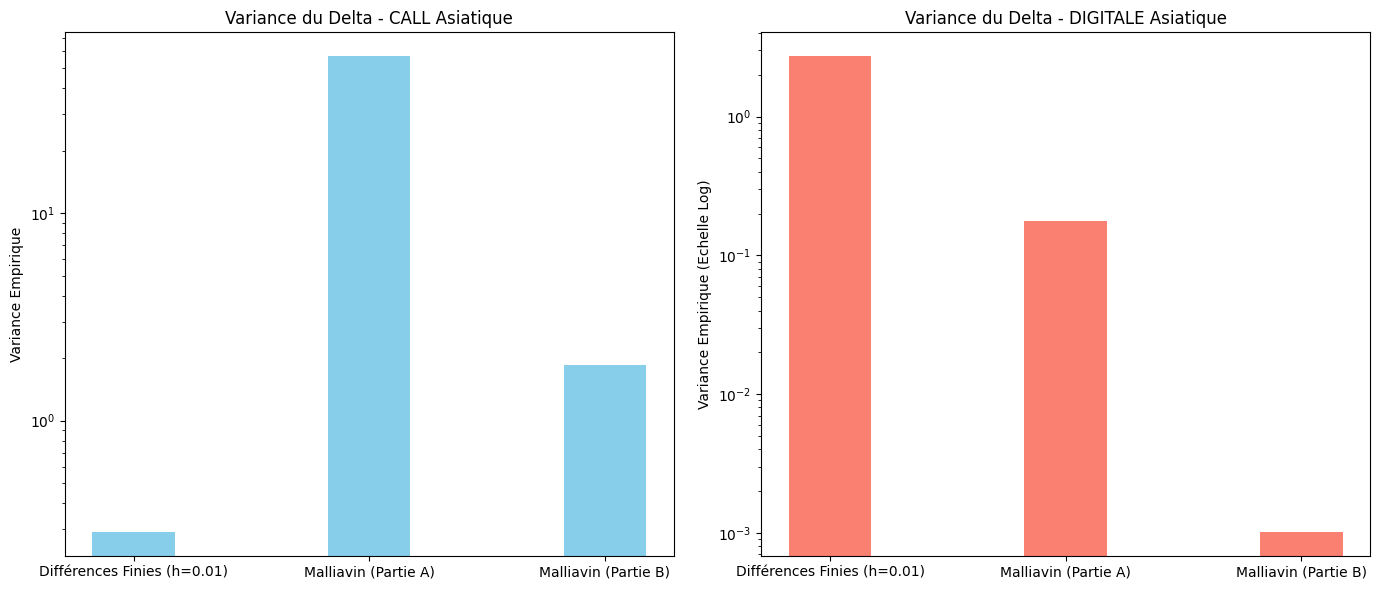

In [11]:
# Choix du paramètre h = 0.01 pour la DF dans la comparaison
h_comp = 0.01
var_call = [res_df[h_comp]['call_var'], np.var(delta_ca, ddof=1), np.var(delta_cb, ddof=1)]
var_dig = [res_df[h_comp]['dig_var'], np.var(delta_da, ddof=1), np.var(delta_db, ddof=1)]

labels = ['Différences Finies (h=0.01)', 'Malliavin (Partie A)', 'Malliavin (Partie B)']

x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14, 6))

# Subplot 1 : Call Asiatique
plt.subplot(1, 2, 1)
bars1 = plt.bar(x_pos, var_call, width, color='skyblue')
plt.ylabel('Variance Empirique')
plt.title('Variance du Delta - CALL Asiatique')
plt.xticks(x_pos, labels)
plt.yscale('log') # Echelle log très utile car la DF explose pour la digitale

# Subplot 2 : Digitale Asiatique
plt.subplot(1, 2, 2)
bars2 = plt.bar(x_pos, var_dig, width, color='salmon')
plt.ylabel('Variance Empirique (Echelle Log)')
plt.title('Variance du Delta - DIGITALE Asiatique')
plt.xticks(x_pos, labels)
plt.yscale('log') 

plt.tight_layout()
plt.show()

### Question e

L'implémentation met parfaitement en évidence la force principale du Calcul de Malliavin pour le pricing de sensibilités en finance.

- Lorsque le payoff est régulier (comme le Call), la méthode historique des différences finies (surtout avec des variables communes) reste extrêmement performante et fournit les variances les plus faibles. La méthode B de Malliavin, en intégrant sur tout le chemin, est également tout à fait satisfaisante. La méthode A, en revanche, concentre tout le bruit sur le premier pas de temps très court, causant une variance rédhibitoire.

- Lorsque le payoff est singulier ou discontinu (comme la Digitale), la méthode des Différences Finies montre ses graves limites. Dès qu'on rend $h$ petit pour annuler le biais, la variance de la méthode diverge vers l'infini, l'estimateur devenant inutilisable en pratique. À l'inverse, les méthodes basées sur Malliavin ignorent mathématiquement la discontinuité du payoff en transférant la dérivation directement sur la dynamique de l'actif sous-jacent. Elles garantissent ainsi une variance maîtrisée et un calcul des "Grecs" parfaitement robuste. La Méthode B se révèle ici être le compromis ultime par sa stabilité.